# Section 5: Optimal Model Selection
### Lecture 17: Threshold Optimization using Performance Metrics

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import xgboost as xgb

df = pd.read_csv('../Modulo2/creditcard.csv.zip')
y = df['Class']
X = df.drop(['Class','Amount','Time'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42, stratify=y)
#model_xgb = xgb.XGBClassifier(max_depth=5, scale_pos_weight=100)
model_xgb = xgb.XGBClassifier(max_depth=4, scale_pos_weight=100)
model_xgb.fit(X_train, y_train)
y_pred = model_xgb.predict(X_test)
confusion_matrix(y_test, y_pred)

array([[28424,     8],
       [    7,    42]])

In [73]:
conf_matrix_xgb=confusion_matrix(y_test, y_pred)

print('True negatives TN - actually non-fraudulent and correctly classified as non-fraudulent')
print(conf_matrix_xgb[0][0]) #normal 
print('False positives FP - actually non-fraudulent but incorrectly classified as fraud')
print(conf_matrix_xgb[0][1]) # normal but predicted fraud 
print('False negatives FN - actually fraud but incorrectly classified as being non-fraudulent')
print(conf_matrix_xgb[1][0]) # fraud but predicted normal 
print('True positives TP - actually fraud and correctly classified as fraud')
print(conf_matrix_xgb[1][1]) # Fraud 

True negatives TN - actually non-fraudulent and correctly classified as non-fraudulent
28424
False positives FP - actually non-fraudulent but incorrectly classified as fraud
8
False negatives FN - actually fraud but incorrectly classified as being non-fraudulent
7
True positives TP - actually fraud and correctly classified as fraud
42


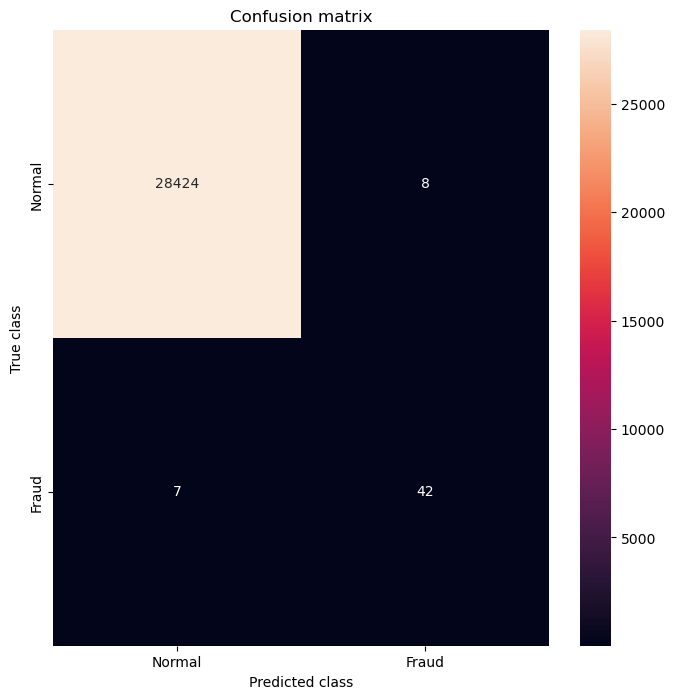

In [74]:
LABELS = ["Normal", "Fraud"]

plt.figure(figsize=(8, 8))
sns.heatmap(conf_matrix_xgb, xticklabels=LABELS, yticklabels=LABELS, annot=True, fmt="d")
plt.title("Confusion matrix")
plt.ylabel('True class')
plt.xlabel('Predicted class')
plt.show()

In [75]:
# probability of being fraudulent
y_pred = model_xgb.predict_proba(X_test)[:,1]
y_pred

array([8.2496219e-05, 1.3255234e-06, 5.3313283e-06, ..., 6.3598222e-06,
       2.3700036e-06, 5.3437839e-06], dtype=float32)

### Otimizar

1) numpy é usado para criar intervalos de thresholds (limiares de decisão).

average_precision_score calcula a média de precisão (Average Precision, que é o AUPRC – Area Under the Precision-Recall Curve).

In [76]:
import numpy as np
from sklearn.metrics import average_precision_score

2) Preparando listas para armazenar resultados

Vai guardar os valores de limiares (thresholds) e os respectivos AUPRCs obtidos.

In [77]:
threshold_list = []
auprc_list = []

3) Gerando thresholds

Em porcentagem

Cria 100 valores igualmente espaçados entre 0 e 1.

Cada valor será testado como limite para transformar probabilidades (y_pred) em previsões binárias (0 ou 1).

In [78]:
thresholds = np.linspace(0, 1, 100) # em porcentagem

4) Loop de avaliação

In [79]:



for threshold in thresholds:
    y_pred_thresh = [1 if e > threshold else 0 for e in y_pred]
    threshold_list.append(threshold)
    
    # AUPRC
    auprc_score = average_precision_score(y_test, y_pred_thresh)
    auprc_list.append(auprc_score)


Para cada threshold:

Converte as probabilidades previstas (y_pred) em classe 0 ou 1.

Calcula o AUPRC entre y_test (valores reais) e y_pred_thresh (classificação com aquele threshold).

Armazena o threshold e o AUPRC correspondente.

⚠️ Aqui existe um detalhe: normalmente o average_precision_score é usado diretamente com probabilidades (y_pred), não com previsões binárias (predict_proba). Usar y_pred_thresh pode achatar a métrica e dar menos informação do que esperado.

In [80]:
threshold_list[:20]

[0.0,
 0.010101010101010102,
 0.020202020202020204,
 0.030303030303030304,
 0.04040404040404041,
 0.05050505050505051,
 0.06060606060606061,
 0.07070707070707072,
 0.08080808080808081,
 0.09090909090909091,
 0.10101010101010102,
 0.11111111111111112,
 0.12121212121212122,
 0.13131313131313133,
 0.14141414141414144,
 0.15151515151515152,
 0.16161616161616163,
 0.17171717171717174,
 0.18181818181818182,
 0.19191919191919193]

In [81]:
auprc_list[:20]

[0.0017204452090867595,
 0.19480710283374117,
 0.29069176211617337,
 0.33219407732797235,
 0.387530497610371,
 0.42501645973715724,
 0.43917782320727644,
 0.4718943402296841,
 0.4902716262090109,
 0.5033399184609766,
 0.5316852284159445,
 0.5392777221538824,
 0.5719484527837966,
 0.5719484527837966,
 0.5807444187226197,
 0.589815258597031,
 0.589815258597031,
 0.6088347615595063,
 0.6188122057365426,
 0.6188122057365426]

In [82]:

# plot curve
threshold_df = pd.DataFrame(threshold_list, auprc_list).reset_index()
threshold_df.columns = ['AUPRC', 'Threshold']
threshold_df.tail(5)

,AUPRC,Threshold
95,0.777770,0.959596
96,0.757444,0.969697
97,0.716800,0.979798
98,0.735652,0.989899
99,0.001720,1.000000


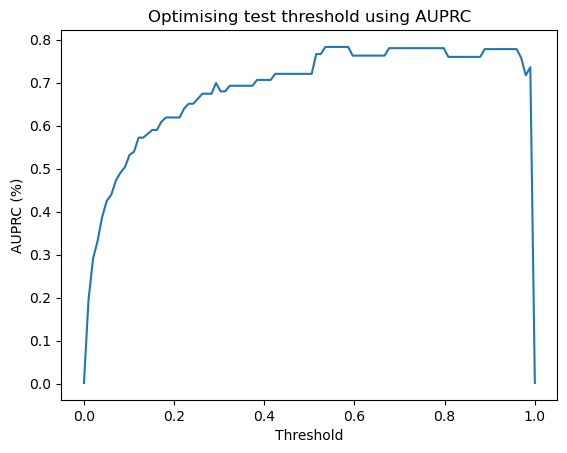

In [83]:


plt.plot(threshold_df['Threshold'], threshold_df['AUPRC'])
plt.title("Optimising test threshold using AUPRC")
plt.xlabel('Threshold')
plt.ylabel('AUPRC (%)')
plt.savefig('Optimising threshold using AUPRC');
plt.show()

In [84]:
threshold_df.sort_values(by='AUPRC', ascending=False)

,AUPRC,Threshold
56,0.782854,0.565657
58,0.782854,0.585859
53,0.782854,0.535354
54,0.782854,0.545455
55,0.782854,0.555556
...,...,...
3,0.332194,0.030303
2,0.290692,0.020202
1,0.194807,0.010101
0,0.001720,0.000000


In [85]:
#threshold_df.loc[(threshold_df['AUPRC'] >= 0.82)]

In [86]:
threshold_df.loc[(threshold_df['AUPRC'] >= 0.78)] # double check

,AUPRC,Threshold
53,0.782854,0.535354
54,0.782854,0.545455
55,0.782854,0.555556
56,0.782854,0.565657
57,0.782854,0.575758
58,0.782854,0.585859


# exemplo correto

In [87]:
threshold_df = pd.DataFrame({
    'Threshold': threshold_list,
    'AUPRC': auprc_list
})

In [91]:
len(threshold_df)

100

In [88]:
threshold_df.sort_values(by='AUPRC', ascending=False).head(20)

,Threshold,AUPRC
56,0.565657,0.782854
58,0.585859,0.782854
53,0.535354,0.782854
54,0.545455,0.782854
55,0.555556,0.782854
57,0.575758,0.782854
72,0.727273,0.779965
73,0.737374,0.779965
69,0.696970,0.779965
75,0.757576,0.779965


In [89]:
threshold_df.loc[(threshold_df['AUPRC'] >= 0.78)] # double check

,Threshold,AUPRC
53,0.535354,0.782854
54,0.545455,0.782854
55,0.555556,0.782854
56,0.565657,0.782854
57,0.575758,0.782854
58,0.585859,0.782854


Plota a curva Threshold vs AUPRC, mostrando como a escolha do limiar impacta a performance do modelo em termos de AUPRC.

### Permite identificar o melhor threshold (aquele com maior AUPRC).

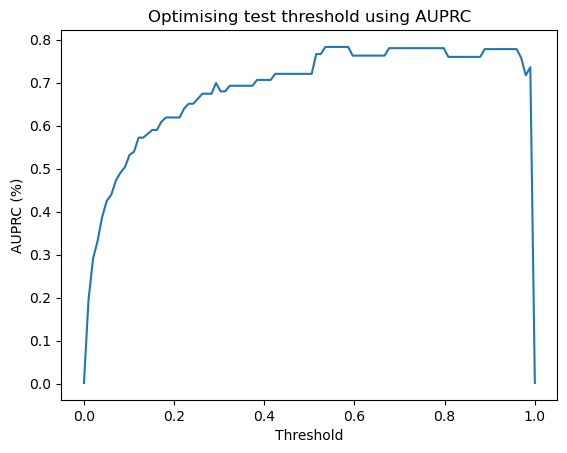

In [90]:

plt.plot(threshold_df['Threshold'], threshold_df['AUPRC'])
plt.title("Optimising test threshold using AUPRC")
plt.xlabel('Threshold')
plt.ylabel('AUPRC (%)')
plt.savefig('Optimising threshold using AUPRC');
plt.show()

Esse código testa vários thresholds para transformar probabilidades em classificações binárias e avalia o desempenho em termos de AUPRC. 

Com curva para visualizar qual threshold maximiza a métrica.

O AUPRC (Area Under the Precision–Recall Curve) é a área sob a curva de Precisão vs Revocação (ou Precision vs Recall).
Ele é calculado a partir da média de precisão (Average Precision), que usa integração por soma de retângulos (estilo método trapezoidal, mas ponderando cada recall step).

Exemplo:

No fim, teremos 4 possíveis situações:

Realidade	Predição	Nome

Fraude (1)	Fraude (1)	✅ Verdadeiro Positivo (TP)

Não fraude (0)	Não fraude (0)	✅ Verdadeiro Negativo (TN)

Não fraude (0)	Fraude (1)	❌ Falso Positivo (FP)

Fraude (1)	Não fraude (0)	❌ Falso Negativo (FN)

### Cálculo do AUPRC

1. Definir métricas básicas:

Precisão (Precision)

- $\( Precision = \frac{TP}{TP + FP} \)$
 
De todas as transações que o modelo disse que são fraudes, quantas realmente eram fraude?

➡️ Responde: “Quando o modelo grita FRAUDE, qual a chance dele estar certo?”


Revocação (Recall)

- $\( Recall = \frac{TP}{TP + FN} \)$

De todas as transações que eram fraude de verdade, quantas o modelo conseguiu encontrar?

➡️ Responde: “O modelo consegue capturar a maior parte das fraudes?”


2. Construir a curva Precision-Recall variando o threshold.

3. Calcular a área sob a curva:
$\[
AP = \sum_{n} (Recall_n - Recall_{n-1}) \cdot Precision_n
\]$


Ou seja:

Ordena as predições pelo score (y_pred).

Vai aumentando o recall a cada ponto.

A cada incremento de recall, pega a precisão naquele ponto e multiplica pela diferença no recall.

Isso equivale a calcular a área sob a curva Precision-Recall.


No `scikit-learn`, isso é feito com:
```python
from sklearn.metrics import average_precision_score
auprc = average_precision_score(y_true, y_scores)

Diferença intuitiva

### Alta Precisão, Baixa Revocação

O modelo só acusa fraude quando tem certeza.

Quase nunca erra (poucos falsos positivos), mas deixa passar muitas fraudes (muitos falsos negativos).

Exemplo: polícia só prende quando tem prova de vídeo — pega poucos criminosos, mas todos são realmente culpados.

### Alta Revocação, Baixa Precisão

O modelo marca quase tudo como fraude.

Pega quase todas as fraudes (quase nenhum FN), mas erra muito (muitos FP).

Exemplo: polícia prende todo mundo na rua para garantir que os culpados estão entre eles.

📊 Mini exemplo 

Suponha:

10 transações

4 fraudes de verdade (y_test)

O modelo previu 5 como fraude

Resultado:

TP = 3 (fraudes reais que o modelo achou)

FP = 2 (transações normais que o modelo disse que eram fraude)

FN = 1 (fraude real que o modelo deixou passar)

TN = 4

Cálculo:
Precision= 3/ (3+2) =0.6(60%)


Recall= 3/ (3+1) =0.75(75%)

👉 Resumo:

Precisão = quão confiáveis são as previsões positivas.

Recall = quão bem o modelo encontra os positivos reais.